In [1]:
!pip install rasterio

  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
    --------------------------------------- 0.5/25.7 MB 2.8 MB/s eta 0:00:09
   --- ------------------------------------ 2.1/25.7 MB 5.9 MB/s eta 0:00:05
   -------- ------------------------------- 5.8/25.7 MB 10.4 MB/s eta 0:00:02
   --------- ------------------------------ 6.3/25.7 MB 8.0 MB/s eta 0:00:03
   ------------ --------------------------- 7.9/25.7 MB 8.5 MB/s eta 0:00:03
   -------------- ------------------------- 9.4/25.7 MB 8.2 MB/s eta 0:00:02
   ----------------- ---------------------- 11.0/25.7 MB 7.7 MB/s eta 0:00:02
   ------------------- -------------------- 12.3/25.7 MB 7.5 MB/s eta 0:00:02
   -------------------- ------------------- 13.4/25.7 MB 7.4 MB/s eta 0:00:02
   ----------------------

In [2]:
import urllib.request

url = "https://github.com/rasterio/rasterio/raw/main/tests/data/RGB.byte.tif"
urllib.request.urlretrieve(url, "sample-data/sample_raster.tif")
print("done")

done


In [3]:
import rasterio
dataset = rasterio.open("sample-data/sample_raster.tif")

print(dataset.width)
print(dataset.height)
print(dataset.count)
print(dataset.crs)

791
718
3
EPSG:32618


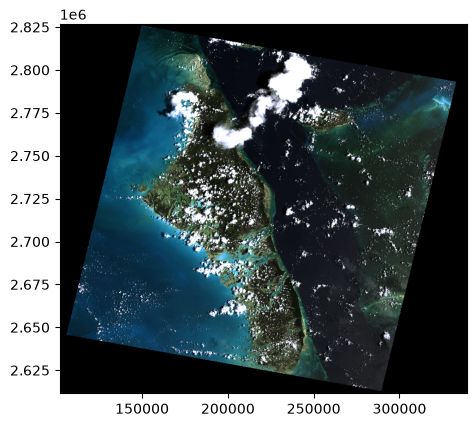

<Axes: >

In [4]:
from rasterio.plot import show

show(dataset)

In [ ]:
band1 = dataset.read(1)
print(band1.shape)
print(band1)

In [ ]:
band1 = dataset.read(1)
print(band1.shape)
print(band1.min(), band1.max(), band1.mean())

In [5]:
band1 = dataset.read(1)
print(band1.shape)
print(band1)

(718, 791)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [6]:
band1 = dataset.read(1)
print(band1.shape)
print(band1.min(), band1.max(), band1.mean())

(718, 791)
0 255 29.94772668847656


In [7]:
small_section = band1[100:300, 100:300]
print(small_section.shape)

(200, 200)


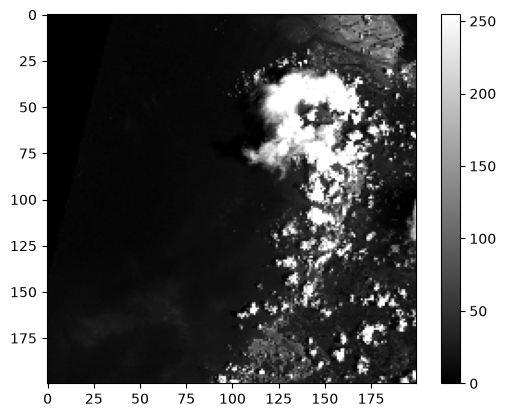

In [8]:
import matplotlib.pyplot as plt

plt.imshow(small_section, cmap="gray")
plt.colorbar()
plt.show()

In [9]:
with rasterio.open(
    "sample-data/cropped_band1.tif",
    "w",
    driver="GTiff",
    height=small_section.shape[0],
    width=small_section.shape[1],
    count=1,
    dtype=small_section.dtype,
    crs=dataset.crs,
) as new_file:
    new_file.write(small_section, 1)

print("saved")

saved


C:\Users\Administrator\miniconda3\envs\gis-refresh\Lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
